In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
data = {
    'word_frequency': [2, 5, 1, 8, 3, 9, 2, 7, 4, 10, 1, 6],
    'message_length': [20, 35, 15, 80, 25, 90, 18, 70, 30, 100, 12, 65],
    'spam': [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

data = pd.DataFrame(data)

print(data)

    word_frequency  message_length  spam
0                2              20     0
1                5              35     0
2                1              15     0
3                8              80     1
4                3              25     0
5                9              90     1
6                2              18     0
7                7              70     1
8                4              30     0
9               10             100     1
10               1              12     0
11               6              65     1


In [3]:
print(data.isnull().sum())

word_frequency    0
message_length    0
spam              0
dtype: int64


In [4]:
x = data[['word_frequency', 'message_length']]
y = data['spam']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    random_state=5
)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(8, 2)
(8,)
(4, 2)
(4,)


In [6]:
model = SVC(kernel='rbf', random_state=0)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("SVM Prediction:")
print(y_pred)

SVM Prediction:
[1 1 0 1]


In [7]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

Confusion Matrix:
[[1 0]
 [0 3]]
Accuracy Score: 1.0
Accuracy in Percentage: 100 %


In [8]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



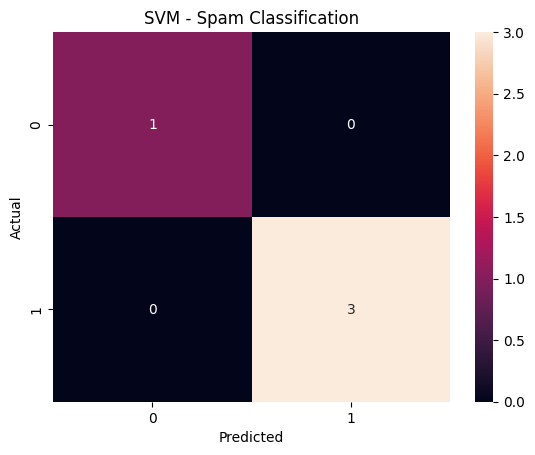

In [9]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)
plt.title("SVM - Spam Classification")
plt.show()